# Lab3 Model Quantization
## Setup
### Install python package

In [1]:
%pip install torch torchinfo torchsummary torchvision tqdm numpy matplotlib seaborn scikit-learn -q 


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Environment Setup

In [1]:
import os
import math
import copy
import time
import torch
import platform
import warnings
import numpy as np
import seaborn as sns
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.ao.quantization as tq

from enum import Enum
from tqdm.notebook import tqdm
from typing import Tuple
from torchsummary import summary
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import RandAugment
from sklearn.metrics import confusion_matrix

from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR

# Select device
DEFAULT_DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# Ignore warnings in Pytorch2.8 when using torch.ao.quantization
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Set quantization backend based on CPU architecture
machine = platform.machine().lower()
if "x86" in machine or "amd64" in machine:
    torch.backends.quantized.engine = 'fbgemm'
elif "arm" in machine or "aarch64" in machine:
    torch.backends.quantized.engine = 'qnnpack'
else:
    print("Unsupported machine:", machine)

# Check environment information
print("Pytorch version:", torch.__version__)
print(f"Using {torch.backends.quantized.engine} backend {machine}")
print("Using device:", DEFAULT_DEVICE)

Pytorch version: 2.8.0+cu128
Using fbgemm backend x86_64
Using device: cuda:0


### Load CIFAR-10 Dataset

In [2]:
# def get_loaders(
#     source, batch_size: int, transform, eval_transform=None,
#     root: str = "data", split_ratio: float = 0.1
# ) -> Tuple[DataLoader, DataLoader, DataLoader]:
#     if eval_transform is None:
#         eval_transform = transform

#     trainset = source(root=root, train=True, download=True, transform=transform)
#     testset  = source(root=root, train=False, download=True, transform=eval_transform)

#     val_len = int(split_ratio * len(trainset))
#     train_len = len(trainset) - val_len
#     trainset, valset = torch.utils.data.random_split(trainset, [train_len, val_len])

#     loader_kwargs = dict(batch_size=batch_size, num_workers=4, pin_memory=True)
#     trainloader = DataLoader(trainset, shuffle=True, **loader_kwargs)
#     valloader  = DataLoader(valset, shuffle=True, **loader_kwargs)
#     testloader = DataLoader(testset, shuffle=False, **loader_kwargs)

#     return trainloader, valloader, testloader


def get_loaders(
    source,
    batch_size: int,
    transform,  # train augment (含 RandAugment)
    eval_transform=None,  # val/test 僅 Normalize
    root: str = "data",
    split_ratio: float = 0.1,
    seed: int = 42,
    num_workers: int = 4,
    pin_memory: bool = True,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    建立三個 DataLoader：
      - trainloader：使用 train 視圖（含資料增強）
      - valloader / testloader：使用 eval 視圖（不含增強）
    兩個視圖底層皆指向同一份 CIFAR-10 資料，但 transform 不同。
    """
    if eval_transform is None:
        eval_transform = transform  # 若未提供，沿用 train（不建議，但保留相容性）

    # --- 兩個視圖（view）---
    train_view = source(root=root, train=True, download=True, transform=transform)
    eval_view = source(root=root, train=True, download=False, transform=eval_transform)
    testset = source(root=root, train=False, download=False, transform=eval_transform)

    # --- 一致的索引切分 ---
    n = len(train_view)
    val_len = int(round(split_ratio * n))
    train_len = n - val_len
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g).tolist()
    train_idx, val_idx = perm[:train_len], perm[train_len:]

    # --- 對應到不同視圖 ---
    trainset = Subset(train_view, train_idx)  # 有增強
    valset = Subset(eval_view, val_idx)  # 僅 Normalize
    # testset 直接用 eval_transform

    loader_kwargs = dict(
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory and torch.cuda.is_available(),
        persistent_workers=(num_workers > 0),
    )

    trainloader = DataLoader(trainset, shuffle=True, drop_last=False, **loader_kwargs)
    valloader = DataLoader(valset, shuffle=False, drop_last=False, **loader_kwargs)
    testloader = DataLoader(testset, shuffle=False, drop_last=False, **loader_kwargs)
    return trainloader, valloader, testloader


def get_cifar10_loaders(batch_size: int, root="data/cifar10", split_ratio: float = 0.1):
    """
    Create CIFAR-10 training / validation / testing dataloaders.
    
    Args:
        batch_size (int): Number of samples per mini-batch.
        root (str): Path to download/load CIFAR-10 dataset.
        split_ratio (float): Fraction of training set to use for validation.
    
    Returns:
        train_loader, val_loader, test_loader (torch.utils.data.DataLoader)
    """

    train_transform = transforms.Compose(
        [
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(
                brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
            ),
            transforms.RandomRotation(15),
            RandAugment(num_ops=2, magnitude=9),
            transforms.ToTensor(),
            transforms.RandomErasing(
                p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3)
            ),  # 隨機抹除局部區域
            transforms.Normalize(
                mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.243, 0.261]
            ),
        ]
    )

    eval_transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.243, 0.261]
            ),
        ]
    )
    return get_loaders(
        datasets.CIFAR10, batch_size, train_transform,
        eval_transform=eval_transform, root=root, split_ratio=split_ratio
    )

if __name__ == "__main__":
    
    """ You can adjust the numbers below """
    BATCH_SIZE = 128
    VAL_TRAIN_SPLIT_RATIO = 0.1
    
    train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=BATCH_SIZE, split_ratio=VAL_TRAIN_SPLIT_RATIO)
    print(f"CIFAR-10: train={len(train_loader.dataset)}, "
            f"val={len(val_loader.dataset)}, "
            f"test={len(test_loader.dataset)}, "
            f"shape={train_loader.dataset[0][0].shape}")

CIFAR-10: train=45000, val=5000, test=10000, shape=torch.Size([3, 32, 32])


## Model Preparation
### Implement ResNet-50

In [3]:
class QuantizableBasicBlock(nn.Module):
    """
    BasicBlock for ResNet with quantization support.
    """

    expansion = 1
    
    verbose = False

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        # ----- Convolution + BatchNorm + ReLU -----
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=False)

        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.downsample = downsample
        self.stride = stride

        # FloatFunctional() allows fused add+relu in quantized models
        self.add_relu = nn.quantized.FloatFunctional()

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        ##### YOUR CODE HERE #####
        out = self.relu(self.bn1(self.conv1(x)))

        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(identity)

        ##### YOUR CODE HERE #####
        # out = add + relu (skip connection)
        out = self.add_relu.add_relu(out, identity)
        return out

    def fuse_model(self) -> None:
        """
        Fuse Conv-BN-ReLU for quantization.
        """
        if self.training:
            print("Fuse model only for inference!")
            return
        if any(p.is_cuda for p in self.parameters()):
            print("Fuse model only for CPU!")
            return 

        if self.verbose:
            print("Fusing QuantizableBasicBlock...")
        ##### YOUR CODE HERE #####
        # Fuse conv+bn+relu modules
        torch.ao.quantization.fuse_modules(
            self, [["conv1", "bn1", "relu"], ["conv2", "bn2"]], inplace=True
        )

        if self.downsample:
            ##### YOUR CODE HERE #####
            # Fuse downsample conv+bn if exists
            tq.fuse_modules(self.downsample, ["0", "1"], inplace=True)
        if self.verbose:
            print("Fuse completed✅")

class QuantizableBottleneck(nn.Module):
    """
    Bottleneck block for ResNet with quantization support.
    """

    expansion = 4
    verbose = False

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        # 1x1 reduce
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        # 3x3 conv
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        # 1x1 expand
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)

        self.relu1 = nn.ReLU(inplace=False)
        self.relu2 = nn.ReLU(inplace=False)

        self.downsample = downsample
        self.stride = stride

        # FloatFunctional for quantized skip connection
        self.skip_add_relu = nn.quantized.FloatFunctional()

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        ##### YOUR CODE HERE #####
        out = self.relu1(self.bn1(self.conv1(x)))

        out = self.relu2(self.bn2(self.conv2(out)))

        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(identity)

        ##### YOUR CODE HERE #####
        # out = add + relu (skip connection)
        out = self.skip_add_relu.add_relu(out, identity)
        return out

    def fuse_model(self) -> None:
        """
        Fuse Conv-BN-ReLU for quantization.
        """
        ##### YOUR CODE HERE #####
        # Fuse conv+bn+relu modules
        if self.training:
            print("Fuse model only for inference!")
            return
        if any(p.is_cuda for p in self.parameters()):
            print("Fuse model only for CPU!")
            return

        if self.verbose:
            print("Fusing QuantizableBottleneck...")
        tq.fuse_modules(
            self,
            [["conv1", "bn1", "relu1"], ["conv2", "bn2", "relu2"], ["conv3", "bn3"]],
            inplace=True,
        )
        if self.downsample:
            ##### YOUR CODE HERE #####
            # Fuse downsample conv+bn if exists

            if self.downsample:
                tq.fuse_modules(self.downsample, ["0", "1"], inplace=True)

        if self.verbose:
            print("Fuse completed✅")


class QuantizableResNet(nn.Module):
    """
    ResNet model adapted for CIFAR-10 and quantization.
    """
    verbose = False

    def __init__(self, block, layers, num_classes=10):
        super().__init__()
        self.inplanes = 64

        # CIFAR-10 uses 3x3 conv instead of 7x7
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=False)
        self.maxpool = nn.Identity() # no pooling for CIFAR-10

        # Residual layers
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        # Quantization stubs
        self.quant = tq.QuantStub()
        self.dequant = tq.DeQuantStub()

    def _make_layer(self, block, planes, blocks, stride=1):
        """
        Helper function to build ResNet layers.
        """
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        ##### YOUR CODE HERE #####
        # Quantize input
        x = self.quant(x)
        # conv1 -> bn1 -> relu
        x = self.relu(self.bn1(self.conv1(x)))

        # Pass through 4 residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Classification head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        ##### YOUR CODE HERE #####
        # Dequantize output
        x = self.dequant(x)
        return x

    def fuse_model(self) -> None:
        """
        Fuse Conv-BN-ReLU layers in ResNet.
        """
        ##### YOUR CODE HERE #####
        # Fuse conv+bn+relu modules
        if self.training:
            print("Fuse model only for inference!")
            return
        if any(p.is_cuda for p in self.parameters()):
            print("Fuse model only for CPU!")
            return

        if self.verbose:
            print("Fusing QuantizableResNet...")

        tq.fuse_modules(self, [["conv1", "bn1", "relu"]], inplace=True)
        for m in self.modules():
            if type(m) is QuantizableBottleneck or type(m) is QuantizableBasicBlock:
                m.fuse_model()

        if self.verbose:
            print("Fuse completed✅")


def resnet50_cifar10() -> QuantizableResNet:
    """
    Construct a ResNet-50 for CIFAR-10 with quantization support.
    """
    model = QuantizableResNet(QuantizableBottleneck, [3, 4, 6, 3], num_classes=10)
    return model

### Inspect Model Architecture

In [4]:
model = resnet50_cifar10()
summary(model, (3, 32, 32), device= 'cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         QuantStub-1            [-1, 3, 32, 32]               0
            Conv2d-2           [-1, 64, 32, 32]           1,728
       BatchNorm2d-3           [-1, 64, 32, 32]             128
              ReLU-4           [-1, 64, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]           4,096
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
             ReLU-10           [-1, 64, 32, 32]               0
           Conv2d-11          [-1, 256, 32, 32]          16,384
      BatchNorm2d-12          [-1, 256, 32, 32]             512
           Conv2d-13          [-1, 256, 32, 32]          16,384
      BatchNorm2d-14          [-1, 256,

## Utilities

In [5]:
def preprocess_filename(filename: str, existed: str = "keep_both") -> str:
    if existed == "overwrite":
        pass
    elif existed == "keep_both":
        base, ext = os.path.splitext(filename)
        cnt = 1
        while os.path.exists(filename):
            filename = f"{base}-{cnt}{ext}"
            cnt += 1
    elif existed == "raise" and os.path.exists(filename):
        raise FileExistsError(f"{filename} already exists.")
    else:
        raise ValueError(f"Unknown value for 'existed': {existed}")
    return filename

def plot_loss_accuracy(train_loss, train_acc, val_loss, val_acc, filename="loss_accuracy.png"):
    fig, (ax1, ax2) = plt.subplots(1, 2)

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.plot(train_loss, color="tab:blue")
    ax1.plot(val_loss, color="tab:red")
    ax1.legend(["Training", "Validation"])
    ax1.set_title("Loss")

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.plot(train_acc, color="tab:blue")
    ax2.plot(val_acc, color="tab:red")
    ax2.legend(["Training", "Validation"])
    ax2.set_title("Accuracy")

    fig.tight_layout()
    filename = preprocess_filename(filename)
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename)
    print(f"Plot saved at {filename}")

def plot_confusion_matrix(conf_matrix, filename="conf_matrix.png"):
    classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix for CIFAR-10 Classification")
    plt.tight_layout()

    filename = preprocess_filename(filename)
    plt.savefig(filename)
    print(f"Confusion matrix saved to {filename}")

def save_model(model, filename: str, verbose: bool = True, existed: str = "keep_both") -> None:
    filename = preprocess_filename(filename, existed)

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    torch.save(model.state_dict(), filename)
    if verbose:
        print(f"Model saved at {filename} ({os.path.getsize(filename) / 1e6} MB)")
    else:
        print(f"Model saved at {filename}")

def load_model(model, filename: str, qconfig=None, fuse_modules: bool = False, verbose: bool = True) -> torch.nn.Module:
    if fuse_modules and hasattr(model, "fuse_module"):
        print("Fusing modules")
        model.to('cpu').eval()
        model.fuse_model()
    
    if qconfig is not None:
        model.qconfig = qconfig
        qconfig_dict = {"": qconfig}
        model2 = copy.deepcopy(model)
        model_prepared = tq.prepare(model2, qconfig_dict)
        model_int8 = tq.convert(model_prepared)
        model_int8.load_state_dict(torch.load(filename, map_location='cpu', weights_only=False))
        model_int8.eval()
    else:
        device = DEFAULT_DEVICE if qconfig is None else 'cpu'
        model.load_state_dict(torch.load(filename, map_location=device, weights_only=False))

    if verbose:
        print(f"Model loaded from {filename} ({os.path.getsize(filename) / 1e6} MB)")
    return model

## Train Model
### Evaluate Function

In [6]:
def evaluate(model, dataloader, criterion, device=DEFAULT_DEVICE):
    running_loss = 0
    total, correct = 0, 0
    all_preds, all_labels = [], []

    model.eval()
    with torch.no_grad():
        loop = tqdm(dataloader, desc="Evaluating", leave=True,colour="GREEN")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            loss = criterion(output, labels)

            running_loss += loss.item()
            predicted = torch.argmax(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        loop.set_postfix(
            loss=running_loss / (total / images.shape[0]), accuracy=correct / total
        )

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total * 100
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    return avg_loss, accuracy, conf_matrix

from torch.utils.tensorboard import SummaryWriter
import torch


def log_model_weights_to_tensorboard(model, log_dir="runs/qat_debug"):
    model_cpu = model.to("cpu")
    writer = SummaryWriter(log_dir=log_dir)

    for name, param in model_cpu.named_parameters():
        if "weight" in name:
            writer.add_histogram(
                tag=name, values=param.detach().cpu().numpy(), global_step=0
            )

    writer.close()
    print(f"Logged weights to {log_dir}")

2025-11-19 19:10:38.608445: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-19 19:10:38.670843: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-19 19:10:39.933210: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Custom Learning Rate Scheduler

### Training Loop

In [7]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.1,
    is_qat: bool = False,
    device=DEFAULT_DEVICE,
):
    import torch
    import torch.nn as nn
    from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR
    from tqdm import tqdm

    # ✅ 把模型搬到裝置
    model.to(device)

    # ✅ 比較穩的 loss
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # ✅ AdamW 的 LR：FP32 1e-3、QAT 3e-4（原本 0.01 太大）
    base_lr = 3e-4 if is_qat else 1e-3

    # ✅ 參數分組：BN/偏置不做 decay
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if (
            p.dim() == 1
            or n.endswith(".bias")
            or "bn" in n.lower()
            or "downsample.1" in n
        ):
            no_decay.append(p)
        else:
            decay.append(p)

    optimizer = torch.optim.AdamW(
        [
            {"params": decay, "weight_decay": 5e-4},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=base_lr,
        betas=(0.9, 0.999),
        eps=1e-8,
    )

    warmup_epochs = max(1, int(0.1 * epochs))
    warmup = LambdaLR(
        optimizer, lr_lambda=lambda e: float(e + 1) / float(warmup_epochs)
    )
    cosine = CosineAnnealingLR(optimizer, T_max=max(1, epochs - warmup_epochs))
    scheduler = SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])

    # ✅ QAT 後段策略
    def _disable_observer(m):
        if hasattr(m, "disable_observer"):
            m.disable_observer()

    def _freeze_bn(m):
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

    best_val_acc = 0.0
    train_loss_history, train_acc_history = [], []
    val_loss_history, val_acc_history = [], []

    for epoch in range(epochs):
        # QAT 後段穩定化
        if is_qat:
            if epoch >= int(0.8 * epochs):
                model.apply(_disable_observer)
            if epoch >= int(0.9 * epochs):
                model.apply(_freeze_bn)

        model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # ✅ 防爆：梯度裁剪
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({"loss": running_loss / max(1, total)})

        epoch_train_loss = running_loss / max(1, total)
        epoch_train_acc = correct / max(1, total)

        # 驗證
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_running_loss / max(1, val_total)
        val_acc = 100.0 * val_correct / max(1, val_total)

        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc / 100.0)

        print(
            f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_acc*100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_model(
                model,
                (
                    "./weights/QAT_resnet50_cifar10.pth"
                    if is_qat
                    else "./weights/best_resnet50_cifar10.pth"
                ),
                existed="overwrite",
            )

        scheduler.step()

    plot_loss_accuracy(
        train_loss_history,
        train_acc_history,
        val_loss_history,
        val_acc_history,
        filename=(
            "./results/QAT_loss_accuracy.png"
            if is_qat
            else "./results/loss_accuracy.png"
        ),
    )
    return model

### Using early Stopping 

In [8]:
# def train_model(
#     model,
#     train_loader,
#     val_loader,
#     epochs=10,
#     lr=0.1,
#     is_qat: bool = False,
#     device=DEFAULT_DEVICE,
#     # ===== Early Stopping 參數 =====
#     early_stop_patience: int = 15,
#     early_stop_min_delta: float =1e-5,
# ):
#     """
#     Train the model across multiple epochs and validate after each epoch.
#     帶有 Early Stopping（以 validation accuracy 為準）與 Warmup→Cosine LR。
#     """
#     import torch
#     import torch.nn as nn
#     from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR
#     from tqdm import tqdm

#     model.to(device)

#     # ---- 損失、最佳化器、學習率排程 ----
#     criterion = nn.CrossEntropyLoss()
#     base_lr = lr * (0.1 if is_qat else 1.0)

#     optimizer = torch.optim.SGD(
#         model.parameters(), lr=base_lr, momentum=0.9, weight_decay=5e-4, nesterov=True
#     )

#     warmup_epochs = max(0, int(0.05 * epochs))
#     if warmup_epochs > 0:
#         warmup = LambdaLR(
#             optimizer, lr_lambda=lambda e: float(e + 1) / float(warmup_epochs)
#         )
#         cosine = CosineAnnealingLR(
#             optimizer,
#             T_max=max(1, epochs - warmup_epochs)
#         )   
#         scheduler = SequentialLR(
#             optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs]
#         )
#     else:
#         scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

#     # ---- QAT 輔助工具：關 observer / 凍結 BN ----
#     def _disable_observer(m):
#         if hasattr(m, "disable_observer"):
#             m.disable_observer()

#     def _freeze_bn(m):
#         if isinstance(m, nn.BatchNorm2d):
#             m.eval()

#     best_val_acc = 0.0
#     no_improve_epochs = 0  # Early Stopping 計數器

#     train_loss_history, train_acc_history = [], []
#     val_loss_history, val_acc_history = [], []

#     for epoch in range(epochs):
#         # QAT 後段穩定：停用 observer、凍結 BN
#         if is_qat:
#             if epoch >= int(0.8 * epochs):
#                 model.apply(_disable_observer)
#             if epoch >= int(0.9 * epochs):
#                 model.apply(_freeze_bn)

#         # ---- 訓練 ----
#         model.train()
#         running_loss, correct, total = 0.0, 0, 0
#         pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", colour="blue")
#         for images, labels in pbar:
#             images, labels = images.to(device), labels.to(device)

#             optimizer.zero_grad()
#             outputs = model(images)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()

#             running_loss += loss.item() * images.size(0)
#             _, predicted = outputs.max(1)
#             total += labels.size(0)
#             correct += predicted.eq(labels).sum().item()

#             pbar.set_postfix({"loss": running_loss / max(1, total)})

#         epoch_train_loss = running_loss / max(1, total)
#         epoch_train_acc = correct / max(1, total)

#         # ---- 驗證 ----
#         model.eval()
#         val_running_loss, val_correct, val_total = 0.0, 0, 0
#         with torch.no_grad():
#             for images, labels in val_loader:
#                 images, labels = images.to(device), labels.to(device)
#                 outputs = model(images)
#                 loss = criterion(outputs, labels)

#                 val_running_loss += loss.item() * images.size(0)
#                 _, predicted = outputs.max(1)
#                 val_total += labels.size(0)
#                 val_correct += predicted.eq(labels).sum().item()

#         val_loss = val_running_loss / max(1, val_total)
#         val_acc = 100.0 * val_correct / max(1, val_total)

#         # ---- 紀錄 ----
#         train_loss_history.append(epoch_train_loss)
#         train_acc_history.append(epoch_train_acc)
#         val_loss_history.append(val_loss)
#         val_acc_history.append(val_acc / 100.0)

#         current_lr = optimizer.param_groups[0]["lr"]
#         print(
#             f"Epoch {epoch+1} | "
#             f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
#             f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
#             f"Learning Rate: {current_lr:.6f}"
#         )

#         # ---- 最佳模型與 Early Stopping ----
#         improved = val_acc > best_val_acc + early_stop_min_delta
#         if improved:
#             best_val_acc = val_acc
#             no_improve_epochs = 0
#             if not is_qat:
#                 save_model(
#                     model, "./weights/best_resnet50_cifar10.pth", existed="overwrite"
#                 )
#             else:
#                 save_model(
#                     model, "./weights/QAT_resnet50_cifar10.pth", existed="overwrite"
#                 )
#         else:
#             no_improve_epochs += 1

#         # 更新學習率（逐 epoch）
#         if scheduler is not None:
#             scheduler.step()

#         # 觸發 Early Stopping
#         if no_improve_epochs >= early_stop_patience:
#             print(
#                 f"[Early Stopping] No improvement for {no_improve_epochs} epochs. "
#                 f"Best Val Acc = {best_val_acc:.2f}%"
#             )
#             break

#     # ---- 繪圖 ----
#     plot_file = (
#         "./results/QAT_loss_accuracy.png" if is_qat else "./results/loss_accuracy.png"
#     )
#     plot_loss_accuracy(
#         train_loss_history,
#         train_acc_history,
#         val_loss_history,
#         val_acc_history,
#         filename=plot_file,
#     )

#     return model

### Hyperparameter Configuration

Epoch 1/50: 100%|██████████| 352/352 [00:52<00:00,  6.66it/s, loss=1.97]


Epoch 1 | Train Loss: 1.9655 | Train Acc: 31.96% | Val Loss: 1.7921 | Val Acc: 40.78%
Model saved at ./weights/best_resnet50_cifar10.pth (94.408403 MB)


Epoch 2/50: 100%|██████████| 352/352 [00:52<00:00,  6.71it/s, loss=1.66]


Epoch 2 | Train Loss: 1.6569 | Train Acc: 46.90% | Val Loss: 1.5904 | Val Acc: 52.14%
Model saved at ./weights/best_resnet50_cifar10.pth (94.408403 MB)


Epoch 3/50: 100%|██████████| 352/352 [00:52<00:00,  6.71it/s, loss=1.5] 


...

Epoch 49/50: 100%|██████████| 352/352 [00:52<00:00,  6.70it/s, loss=0.646]


Epoch 49 | Train Loss: 0.6461 | Train Acc: 93.48% | Val Loss: 0.7136 | Val Acc: 91.00%
Model saved at ./weights/best_resnet50_cifar10.pth (94.408403 MB)


Epoch 50/50: 100%|██████████| 352/352 [00:52<00:00,  6.70it/s, loss=0.648]


Epoch 50 | Train Loss: 0.6477 | Train Acc: 93.52% | Val Loss: 0.7241 | Val Acc: 90.24%
Plot saved at ./results/loss_accuracy-3.png


QuantizableResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): Identity()
  (layer1): Sequential(
    (0): QuantizableBottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (relu2): ReLU()
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(25

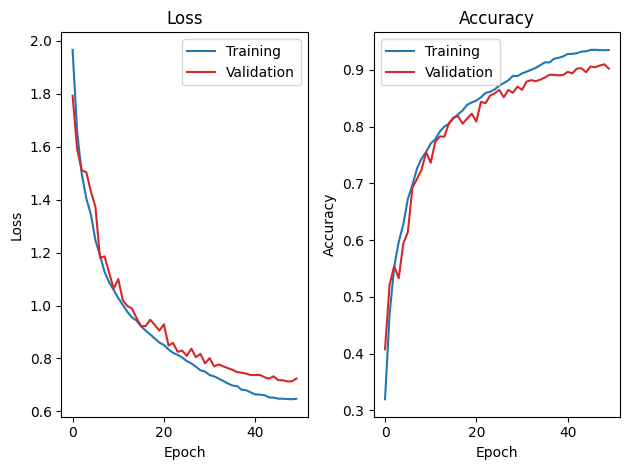

In [10]:
""" You can adjust the numbers below """
EPOCHS = 50
LEARNING_RATE = 1e-4

model = resnet50_cifar10().to(DEFAULT_DEVICE)
train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE)

### Model Testing

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy: 95.38% | Loss: 0.2401
Confusion matrix saved to ./results/confusion_matrix-8.png


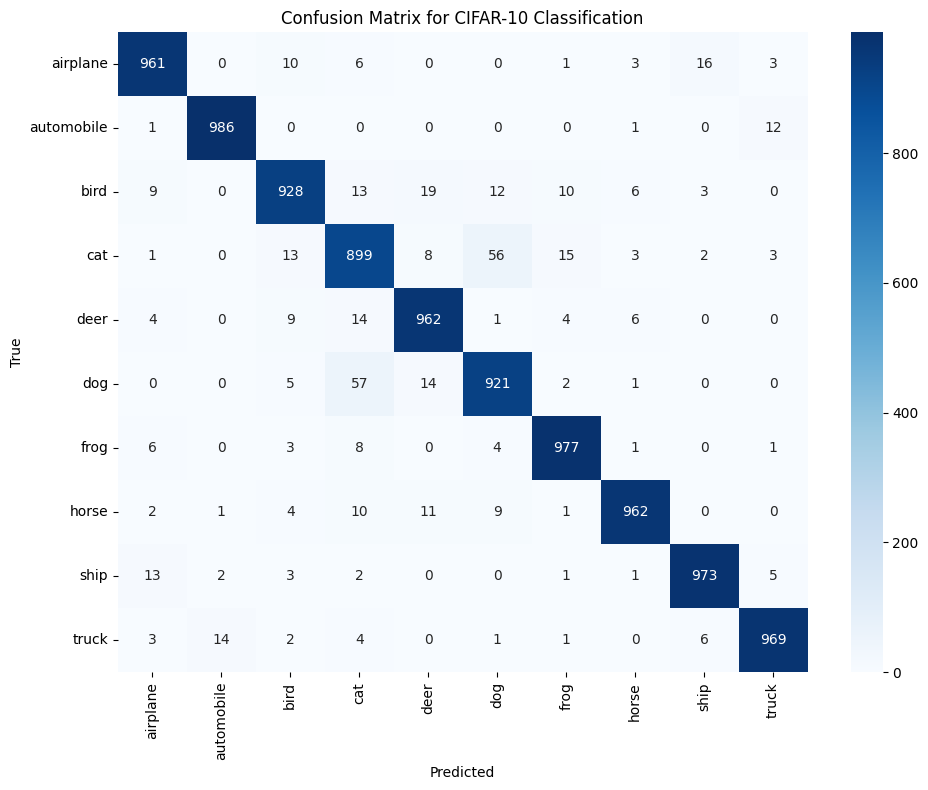

In [8]:
##### YOUR CODE HERE #####
# Implement your criterion
criterion = nn.CrossEntropyLoss()

model = resnet50_cifar10().to(DEFAULT_DEVICE)
model = load_model(model, "./weights/best_resnet50_cifar10.pth", verbose=False)
avg_loss, test_acc, conf_matrix = evaluate(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.2f}% | Loss: {avg_loss:.4f}")
plot_confusion_matrix(conf_matrix, filename="./results/confusion_matrix.png")

## Post-Training Quantization (PTQ)
### Implement Quantization Function

In [9]:
class CusQuantObserver(tq.MinMaxObserver):
    """
    Observer module for your customized customize quantization scheme.
    """

    def scale_approximate(self, scale: float, max_shift_amount=8) -> float:
        # 將 scale 近似為 2^k，k ∈ [-max_shift_amount, max_shift_amount]
        if not math.isfinite(scale) or scale <= 0.0:
            return 1.0
        exp = int(round(math.log2(scale)))
        exp = max(-max_shift_amount, min(max_shift_amount, exp))
        return float(2.0**exp)

    def calculate_qparams(self):
        """Calculates the quantization parameters with scale."""
        min_val, max_val = self.min_val.item(), self.max_val.item()

        """ Calculate zero_point as in the base class """
        ##### YOUR CODE HERE #####
        # 1) 先用父類別邏輯（會依 dtype / qscheme 給出對應的 scale, zero_point）
        base_scale, zero_point = super().calculate_qparams()

        # 2) 讀取 dtype / qscheme 與整數範圍
        dtype   = getattr(self, "dtype", torch.qint8)
        qscheme = getattr(self, "qscheme", torch.per_tensor_symmetric)
        if dtype == torch.qint8:
            qmin, qmax = -128, 127
        elif dtype == torch.quint8:
            qmin, qmax = 0, 255
        else:
            raise ValueError(f"Unsupported dtype: {dtype}")

        # 3) 轉成乾淨的 Python 標量，避免 nested tensor 問題
        scale = float(base_scale.item())
        # zero_point 可能已是 tensor 或標量，統一處理為 int 並 clamp 到合法範圍
        if isinstance(zero_point, torch.Tensor):
            zp = int(zero_point.item())
        else:
            zp = int(zero_point)
        zp = max(qmin, min(qmax, zp))  # 保證在整數範圍內

        # 4) 針對「quint8 + symmetric」 特殊處理 scale / zero_point
        if dtype == torch.quint8 and qscheme == torch.per_tensor_symmetric:
            rng = max(max_val - min_val, 1e-8)
            scale = rng / float(qmax - qmin)
            zp = max(qmin, min(qmax, round(qmin - (min_val / scale))))

        # 5) 套用你的 Po2 近似（若你希望保留；若不想用，可直接註解掉下一行）
        scale = self.scale_approximate(scale)

        # 6) 回傳正確 dtype 的張量
        scale = torch.tensor(scale, dtype=torch.float32)
        zero_point = torch.tensor(zp, dtype=torch.int64)
        return scale, zero_point


    def extra_repr(self):
        return f"min_val={self.min_val}, max_val={self.max_val}, scale=CustomQConfig"


class CustomQConfig(Enum):
    CusQuant = tq.QConfig(
        activation=CusQuantObserver.with_args(
            dtype=torch.quint8, qscheme=torch.per_tensor_symmetric
        ),
        weight=CusQuantObserver.with_args(
            dtype=torch.qint8, qscheme=torch.per_tensor_symmetric
        ),
    )
    DEFAULT = None

### Evaluate Quantized Model

In [10]:
def test_performance(model_fp32, model_int8, dataloader, criterion,
                     is_ptq: bool = True,
                     fp32_file="./weights/best_resnet50_cifar10.pth",
                     int8_file="./weights/PTQ_resnet50_cifar10.pth"
                    ):
    
    device_fp32 = 'cuda' if torch.cuda.is_available() else 'cpu'
    device_int8 = 'cpu'

    model_fp32.to(device_fp32)
    model_int8.to(device_int8)


    # ----- Test accuracy & loss -----
    print("Evaluating FP32 model...")
    loss_fp32, acc_fp32, _ = evaluate(model_fp32, dataloader, criterion, device=device_fp32)
    print(f"[FP32] Loss: {loss_fp32:.4f}, Accuracy: {acc_fp32:.2f}%")

    print("Evaluating INT8 model...")
    loss_int8, acc_int8, _ = evaluate(model_int8, dataloader, criterion, device=device_int8)
    if is_ptq:
        print(f"[PTQ INT8] Loss: {loss_int8:.4f}, Accuracy: {acc_int8:.2f}%")
    else:
        print(f"[QAT INT8] Loss: {loss_int8:.4f}, Accuracy: {acc_int8:.2f}%")


    # ----- Test latency -----
    model_fp32.to('cpu')
    dummy_input = torch.randn(1, 3, 32, 32).to('cpu')

    # FP32
    t0 = time.time()
    with torch.no_grad():
        for _ in range(1000):
            _ = model_fp32(dummy_input)
    t1 = time.time()
    fp32_time = (t1 - t0) / 1000

    # INT8
    t0 = time.time()
    with torch.no_grad():
        for _ in range(1000):
            _ = model_int8(dummy_input)
    t1 = time.time()
    int8_time = (t1 - t0) / 1000

    if is_ptq:
        print(f"[Latency] FP32: {fp32_time*1000:.3f} ms | PTQ INT8: {int8_time*1000:.3f} ms")
    else:
        print(f"[Latency] FP32: {fp32_time*1000:.3f} ms | QAT INT8: {int8_time*1000:.3f} ms")
    print(f"[Speedup] ~{fp32_time/int8_time:.2f}x faster")


    # ----- Compare file size ----- 
    if os.path.exists(fp32_file) and os.path.exists(int8_file):
        size_fp32 = os.path.getsize(fp32_file) / 1e6
        size_int8 = os.path.getsize(int8_file) / 1e6
        if is_ptq:
            print(f"[File size] FP32: {size_fp32:.2f} MB | PTQ INT8: {size_int8:.2f} MB")
        else:
            print(f"[File size] FP32: {size_fp32:.2f} MB | QAT INT8: {size_int8:.2f} MB")
        print(f"[Compression] ~{size_fp32/size_int8:.2f}x smaller")
    else:
        print("Warning: model files not found. Skipping file size comparison.")

### Run PTQ Workflow

In [16]:
def calibrate(model, loader, device= 'cpu'):
    """
    Run one pass of calibration on the dataset to collect statistics 
    for quantization (e.g., min/max values of activations).
    
    Args:
        model (nn.Module): The model prepared for quantization.
        loader (DataLoader): Data loader for calibration dataset.
        device (str): Device to run calibration on.
    """
    ##### YOUR CODE HERE #####
    model.eval().to(device)
    # 校準建議在 CPU；若不是 CPU，仍照指定裝置執行
    with torch.inference_mode():
        for images, _ in loader:
            images = images.to(device)
            _ = model(images)  # 觸發各層 Observer 更新統計


def ptq_quantization():
    """
    Perform Post-Training Quantization (PTQ) on the trained ResNet-50 model.
    
    Steps:
        1. Load CIFAR-10 validation set
        2. Load trained FP32 model
        3. Fuse model layers
        4. Prepare model for PTQ
        5. Calibrate using validation data
        6. Convert model to INT8
        7. Save quantized model
    Returns:
        model_int8 (nn.Module): The INT8 quantized model after PTQ
    """
    # 1. Data
    _, val_loader, _ = get_cifar10_loaders(batch_size=64)

    # 2. Load model (FP32 baseline)
    fp32_checkpoint = "./weights/best_resnet50_cifar10.pth"
    model_fp32 = load_model(resnet50_cifar10(), fp32_checkpoint)

    ##### YOUR CODE HERE #####
    # 3. Fuse layers
    model_fp32.eval().cpu()
    model_fp32.fuse_model()

    # 4. Prepare PTQ
    torch.backends.quantized.engine = "fbgemm"  # x86
    model_fp32.qconfig = CustomQConfig.CusQuant.value
    model_prepared = tq.prepare(model_fp32, inplace=True)
    summary(model_prepared, (3, 32, 32), device="cpu")

    # 5. Calibrate
    calibrate(model_prepared, val_loader, device="cpu")

    # 6. Convert to INT8
    model_int8 = tq.convert(model_prepared, inplace=False)

    # 7. Save INT8 model
    save_model(model_int8, "./weights/PTQ_resnet50_cifar10.pth", existed="overwrite")

    return model_int8

### Compare FP32 vs Quantized Results

In [17]:
if __name__ == "__main__":
    model_int8 = ptq_quantization()

    ##### YOUR CODE HERE #####
    # Implement your criterion
    model_int8.eval().cpu()
    criterion = nn.CrossEntropyLoss()
    try:
        test_loader  # noqa
    except NameError:
        _, _, test_loader = get_cifar10_loaders(batch_size=64)

    fp32_checkpoint = "./weights/best_resnet50_cifar10.pth"
    model_baseline = load_model(resnet50_cifar10(), fp32_checkpoint, verbose=True)
    test_performance(model_baseline, model_int8, test_loader, criterion, is_ptq=True)

Model loaded from ./weights/best_resnet50_cifar10.pth (94.408403 MB)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
  CusQuantObserver-1            [-1, 3, 32, 32]               0
         QuantStub-2            [-1, 3, 32, 32]               0
            Conv2d-3           [-1, 64, 32, 32]           1,792
              ReLU-4           [-1, 64, 32, 32]               0
  CusQuantObserver-5           [-1, 64, 32, 32]               0
  CusQuantObserver-6           [-1, 64, 32, 32]               0
          Identity-7           [-1, 64, 32, 32]               0
          Identity-8           [-1, 64, 32, 32]               0
            Conv2d-9           [-1, 64, 32, 32]           4,160
             ReLU-10           [-1, 64, 32, 32]               0
 CusQuantObserver-11           [-1, 64, 32, 32]               0
 CusQuantObserver-12           [-1, 64, 32, 32]               0
         Identity-13           [-1

KeyboardInterrupt: 

## Quantization-Aware Training (QAT)
### Run QAT Workflow

In [18]:
def qat_quantization():
    """
    Run Quantization-Aware Training (QAT) workflow on ResNet-50 for CIFAR-10.
    
    Steps:
        0. Prepare CIFAR-10 dataloaders
        1. Load pretrained FP32 model
        2. Fuse model layers
        3. Assign QAT qconfig
        4. Prepare model for QAT
        5. Train with QAT
        6. Convert to INT8 model
        7. Save quantized model
    Returns:
        model_int8 (nn.Module): The INT8 quantized model after QAT
    """
    # 1. Data
    train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=64)

    # 2. Load model (FP32 baseline)
    fp32_checkpoint = "./weights/best_resnet50_cifar10.pth"
    model_fp32 = load_model(resnet50_cifar10(), fp32_checkpoint)

    ##### YOUR CODE HERE #####
    # 3. Fuse layers before QAT
    model_fp32.eval().cpu()
    model_fp32.fuse_model()

    # 4. Set qconfig to enable QAT
    model_fp32.qconfig = CustomQConfig.CusQuant.value

    # 5. Prepare model
    model_fp32.train()
    model_prepared = tq.prepare_qat(model_fp32, inplace=False)
    summary(model_prepared, (3, 32, 32), device="cpu")

    # log_model_weights_to_tensorboard(model_prepared)

    # 6. Run QAT training
    # Use train_model(is_qat=True, ...)
    model_trained = train_model(
        model_prepared,
        train_loader,
        val_loader,
        epochs=20,
        lr=0.1,
        is_qat=True,
        device=DEFAULT_DEVICE,
    )

    # 7. Convert to INT8
    model_trained.eval().cpu()
    model_int8 = tq.convert(model_trained, inplace=False)

    # 8. Save INT8 model
    save_model(model_int8, "./weights/QAT_resnet50_cifar10.pth", existed="overwrite")

    return model_int8

if __name__ == "__main__":
    model_int8 = qat_quantization()

    ##### YOUR CODE HERE #####
    # Implement your criterion
    criterion = nn.CrossEntropyLoss()
    try:
        test_loader  # noqa
    except NameError:
        _, _, test_loader = get_cifar10_loaders(batch_size=64)

    fp32_checkpoint = "./weights/best_resnet50_cifar10.pth"
    model_baseline = load_model(resnet50_cifar10(), fp32_checkpoint, verbose=False)
    test_performance(model_baseline, model_int8, test_loader, criterion, is_ptq=False,
                    fp32_file=fp32_checkpoint, int8_file="./weights/QAT_resnet50_cifar10.pth")

Model loaded from ./weights/best_resnet50_cifar10.pth (94.408403 MB)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
  CusQuantObserver-1            [-1, 3, 32, 32]               0
         QuantStub-2            [-1, 3, 32, 32]               0
  CusQuantObserver-3              [-1, 3, 3, 3]               0
  CusQuantObserver-4           [-1, 64, 32, 32]               0
          Identity-5           [-1, 64, 32, 32]               0
          Identity-6           [-1, 64, 32, 32]               0
  CusQuantObserver-7             [-1, 64, 1, 1]               0
  CusQuantObserver-8           [-1, 64, 32, 32]               0
          Identity-9           [-1, 64, 32, 32]               0
         Identity-10           [-1, 64, 32, 32]               0
 CusQuantObserver-11             [-1, 64, 3, 3]               0
 CusQuantObserver-12           [-1, 64, 32, 32]               0
         Identity-13           [-1

Epoch 1/20:  38%|███▊      | 264/704 [00:19<00:32, 13.71it/s, loss=0.676]


KeyboardInterrupt: 